In [1]:
!pip install yfinance pandas

In [2]:
import yfinance as yf
import pandas as pd

tickers = ['MRNA', 'VRTX', 'REGN', 'BIIB', 'ABBV', 'TEVA', 'HCA', 'CVS', 'CI', 'MCK', '^GSPC']

data = yf.download(tickers, start='2018-12-01', end='2024-12-31')['Close']

data.to_csv('healthcare_data.csv')

print(data.shape)
print(data.head())

/tmp/ipykernel_22329/3697664667.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start='2018-12-01', end='2024-12-31')['Close']
[*********************100%***********************]  11 of 11 completed

(1528, 11)
Ticker           ABBV        BIIB          CI        CVS         HCA  \
Date                                                                   
2018-12-03  68.570221  332.190002  204.475510  62.861252  137.405212   
2018-12-04  66.293320  322.730011  198.109543  62.379059  133.497864   
2018-12-06  66.132271  326.700012  194.881058  60.529274  132.295624   
2018-12-07  63.665035  316.730011  187.441940  58.568806  127.608665   
2018-12-10  64.140907  319.440002  187.414688  57.975925  125.974358   

Ticker             MCK       MRNA        REGN       TEVA        VRTX  \
Date                                                                   
2018-12-03  120.588303        NaN  380.042480  21.590000  184.649994   
2018-12-04  118.587334        NaN  370.298340  20.549999  177.929993   
2018-12-06  119.867569        NaN  379.128723  20.260000  179.610001   
2018-12-07  118.483017  18.600000  370.328186  19.410000  172.210007   
2018-12-10  116.738136  18.799999  375.056213  18.44

In [3]:
# Normalize all prices to 100 at start date
normalized = data / data.iloc[0] * 100

print(normalized.head())

Ticker            ABBV        BIIB          CI         CVS         HCA  \
Date                                                                     
2018-12-03  100.000000  100.000000  100.000000  100.000000  100.000000   
2018-12-04   96.679461   97.152235   96.886685   99.232925   97.156332   
2018-12-06   96.444593   98.347334   95.307775   96.290278   96.281372   
2018-12-07   92.846478   95.346040   91.669629   93.171555   92.870324   
2018-12-10   93.540470   96.161835   91.656301   92.228398   91.680916   

Ticker             MCK  MRNA        REGN        TEVA        VRTX       ^GSPC  
Date                                                                          
2018-12-03  100.000000   NaN  100.000000  100.000000  100.000000  100.000000  
2018-12-04   98.340661   NaN   97.436039   95.182951   96.360682   96.763510  
2018-12-06   99.402319   NaN   99.759564   93.839741   97.270515   96.616214  
2018-12-07   98.254154   NaN   97.443892   89.902731   93.262937   94.363112  
2018-12

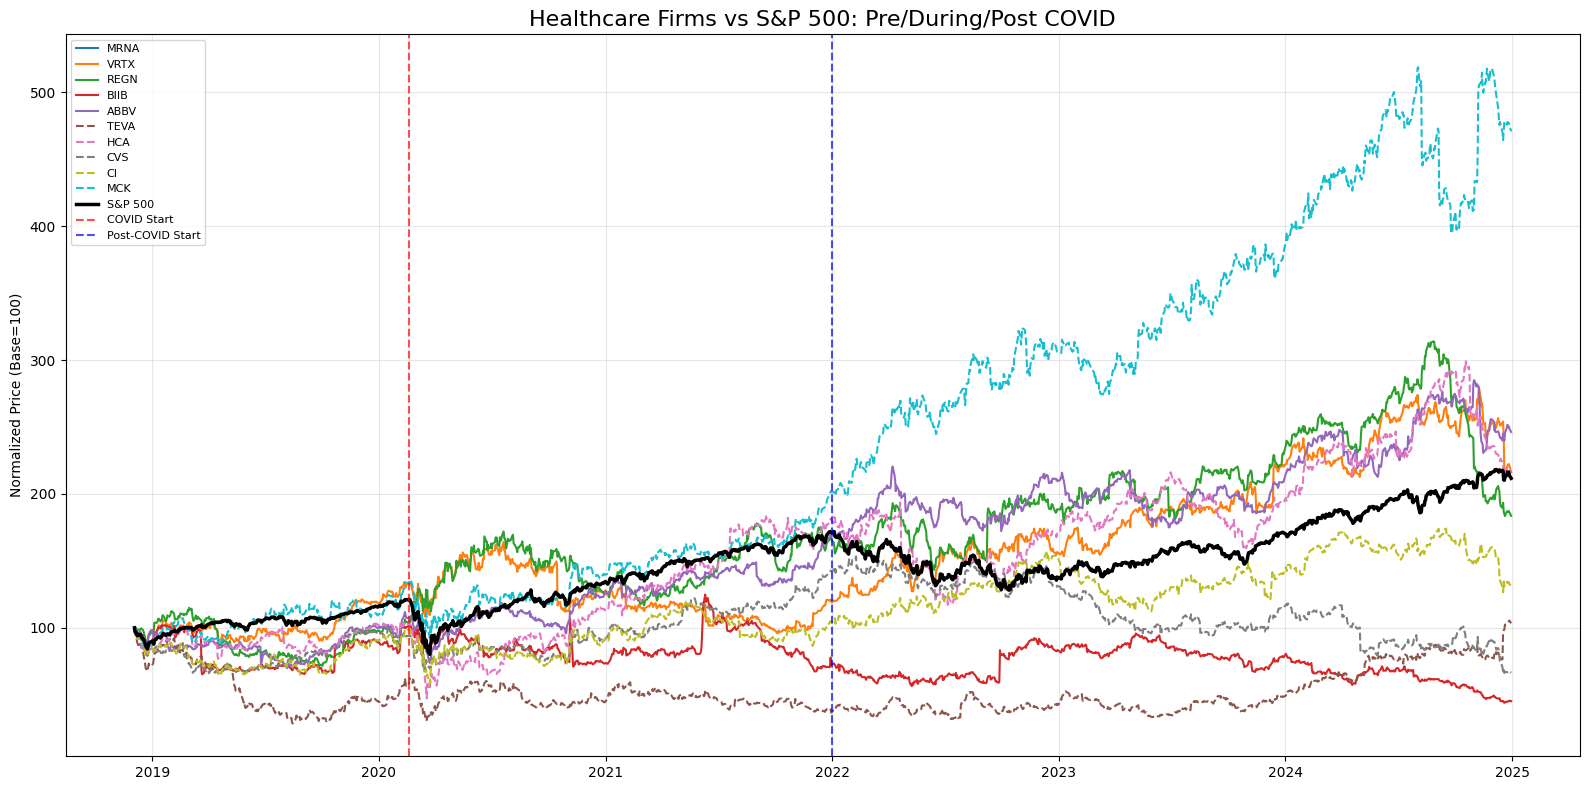

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 8))

# Premium firms in red shades
premium = ['MRNA', 'VRTX', 'REGN', 'BIIB', 'ABBV']
access = ['TEVA', 'HCA', 'CVS', 'CI', 'MCK']

for ticker in premium:
    ax.plot(normalized.index, normalized[ticker], label=ticker, linewidth=1.5)

for ticker in access:
    ax.plot(normalized.index, normalized[ticker], label=ticker, linewidth=1.5, linestyle='dashed')

# S&P 500 as black benchmark
ax.plot(normalized.index, normalized['^GSPC'], label='S&P 500', color='black', linewidth=2.5)

# Mark the three periods
ax.axvline(pd.Timestamp('2020-02-19'), color='red', linestyle='--', alpha=0.7, label='COVID Start')
ax.axvline(pd.Timestamp('2022-01-01'), color='blue', linestyle='--', alpha=0.7, label='Post-COVID Start')

ax.set_title('Healthcare Firms vs S&P 500: Pre/During/Post COVID', fontsize=16)
ax.set_ylabel('Normalized Price (Base=100)')
ax.legend(loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('healthcare_analysis.png', dpi=150)
plt.show()

In [5]:
periods = {
    'Pre-COVID': ('2018-12-03', '2020-02-19'),
    'During-COVID': ('2020-02-20', '2021-12-31'),
    'Post-COVID': ('2022-01-01', '2024-12-31')
}

for period, (start, end) in periods.items():
    subset = normalized.loc[start:end]
    returns = (subset.iloc[-1] / subset.iloc[0] - 1) * 100
    print(f"\n{period} Returns (%):")
    print(returns.round(2).sort_values(ascending=False))


Pre-COVID Returns (%):
Ticker
VRTX     34.19
MCK      33.72
^GSPC    21.35
ABBV      7.63
REGN      4.76
HCA       3.86
BIIB      2.66
CI       -1.49
CVS      -6.02
TEVA    -37.70
MRNA       NaN
dtype: float64

During-COVID Returns (%):
Ticker
HCA      75.95
REGN     58.22
ABBV     56.80
CVS      50.69
MCK      48.42
^GSPC    41.29
CI        6.08
VRTX    -10.40
BIIB    -28.73
TEVA    -39.82
MRNA       NaN
dtype: float64

Post-COVID Returns (%):
Ticker
TEVA     167.95
MCK      133.86
VRTX      79.46
ABBV      45.79
CI        23.60
^GSPC     23.15
HCA       20.68
REGN      12.04
BIIB     -38.48
CVS      -53.61
MRNA        NaN
dtype: float64


In [6]:
mrna = yf.download('MRNA', start='2018-12-01', end='2024-12-31')['Close']
print(mrna.head())
print(mrna.shape)

/tmp/ipykernel_22329/706401226.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  mrna = yf.download('MRNA', start='2018-12-01', end='2024-12-31')['Close']
[*********************100%***********************]  1 of 1 completed

Ticker           MRNA
Date                 
2018-12-07  18.600000
2018-12-10  18.799999
2018-12-11  18.010000
2018-12-12  18.680000
2018-12-13  18.760000
(1525, 1)


In [7]:
# Patch MRNA into the main dataset
data['MRNA'] = mrna

# Re-normalize with MRNA's first valid price as its base
normalized = data.copy()
for col in data.columns:
    first_valid = data[col].first_valid_index()
    normalized[col] = data[col] / data[col].loc[first_valid] * 100

# Recalculate period returns
periods = {
    'Pre-COVID': ('2018-12-07', '2020-02-19'),
    'During-COVID': ('2020-02-20', '2021-12-31'),
    'Post-COVID': ('2022-01-01', '2024-12-31')
}

for period, (start, end) in periods.items():
    subset = normalized.loc[start:end]
    returns = (subset.iloc[-1] / subset.iloc[0] - 1) * 100
    print(f"\n{period} Returns (%):")
    print(returns.round(2).sort_values(ascending=False))


Pre-COVID Returns (%):
Ticker
VRTX     43.88
MCK      36.10
^GSPC    28.60
ABBV     15.92
HCA      11.84
BIIB      7.68
REGN      7.50
CI        7.46
MRNA      1.72
CVS       0.87
TEVA    -30.71
dtype: float64

During-COVID Returns (%):
Ticker
MRNA     1269.90
HCA        75.95
REGN       58.22
ABBV       56.80
CVS        50.69
MCK        48.42
^GSPC      41.29
CI          6.08
VRTX      -10.40
BIIB      -28.73
TEVA      -39.82
dtype: float64

Post-COVID Returns (%):
Ticker
TEVA     167.95
MCK      133.86
VRTX      79.46
ABBV      45.79
CI        23.60
^GSPC     23.15
HCA       20.68
REGN      12.04
BIIB     -38.48
CVS      -53.61
MRNA     -83.25
dtype: float64


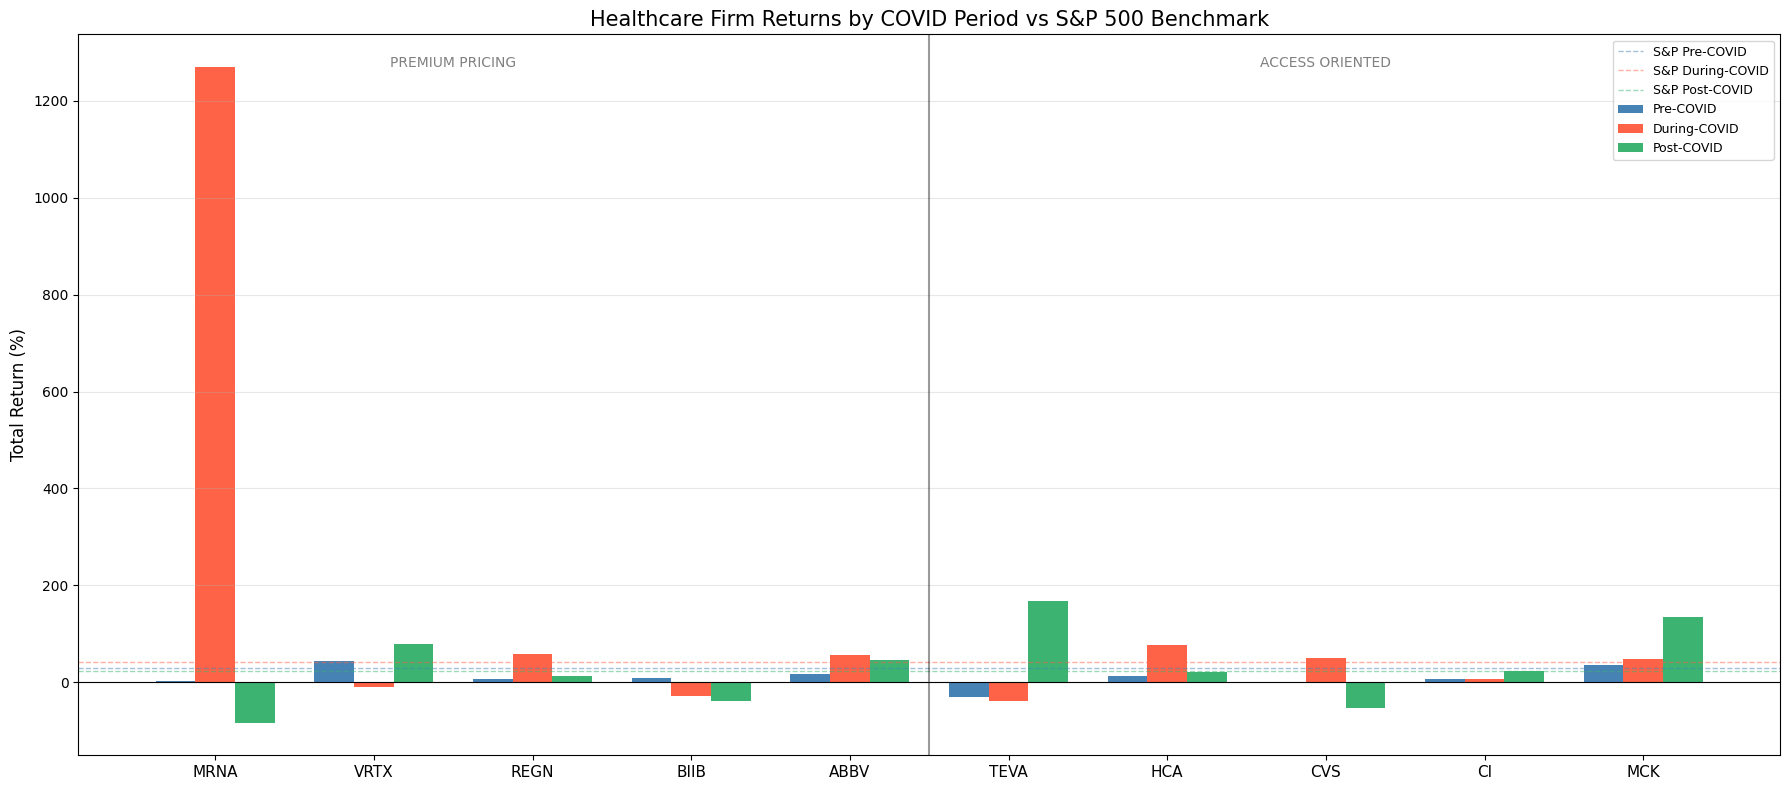

In [8]:
import numpy as np

# Bar chart of returns by period for all firms
periods_data = {
    'Pre-COVID': ('2018-12-07', '2020-02-19'),
    'During-COVID': ('2020-02-20', '2021-12-31'),
    'Post-COVID': ('2022-01-01', '2024-12-31')
}

tickers_ordered = ['MRNA', 'VRTX', 'REGN', 'BIIB', 'ABBV', 'TEVA', 'HCA', 'CVS', 'CI', 'MCK']
period_names = list(periods_data.keys())

returns_matrix = {}
for period, (start, end) in periods_data.items():
    subset = normalized.loc[start:end]
    returns = (subset.iloc[-1] / subset.iloc[0] - 1) * 100
    returns_matrix[period] = returns

x = np.arange(len(tickers_ordered))
width = 0.25

fig, ax = plt.subplots(figsize=(18, 8))

bars1 = ax.bar(x - width, [returns_matrix['Pre-COVID'][t] for t in tickers_ordered], width, label='Pre-COVID', color='steelblue')
bars2 = ax.bar(x, [returns_matrix['During-COVID'][t] for t in tickers_ordered], width, label='During-COVID', color='tomato')
bars3 = ax.bar(x + width, [returns_matrix['Post-COVID'][t] for t in tickers_ordered], width, label='Post-COVID', color='mediumseagreen')

ax.axhline(y=0, color='black', linewidth=0.8)
ax.axhline(y=28.60, color='steelblue', linewidth=1, linestyle='--', alpha=0.5, label='S&P Pre-COVID')
ax.axhline(y=41.29, color='tomato', linewidth=1, linestyle='--', alpha=0.5, label='S&P During-COVID')
ax.axhline(y=23.15, color='mediumseagreen', linewidth=1, linestyle='--', alpha=0.5, label='S&P Post-COVID')

ax.set_xticks(x)
ax.set_xticklabels(tickers_ordered, fontsize=11)
ax.set_ylabel('Total Return (%)', fontsize=12)
ax.set_title('Healthcare Firm Returns by COVID Period vs S&P 500 Benchmark', fontsize=15)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Add divider between premium and access firms
ax.axvline(x=4.5, color='black', linewidth=1.5, linestyle='-', alpha=0.4)
ax.text(1.5, ax.get_ylim()[1]*0.95, 'PREMIUM PRICING', ha='center', fontsize=10, color='gray')
ax.text(7, ax.get_ylim()[1]*0.95, 'ACCESS ORIENTED', ha='center', fontsize=10, color='gray')

plt.tight_layout()
plt.savefig('returns_by_period.png', dpi=150)
plt.show()

/tmp/ipykernel_2102/2378982251.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start='2018-12-01', end='2024-12-31')['Close']
[*********************100%***********************]  11 of 11 completed
/tmp/ipykernel_2102/2378982251.py:53: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


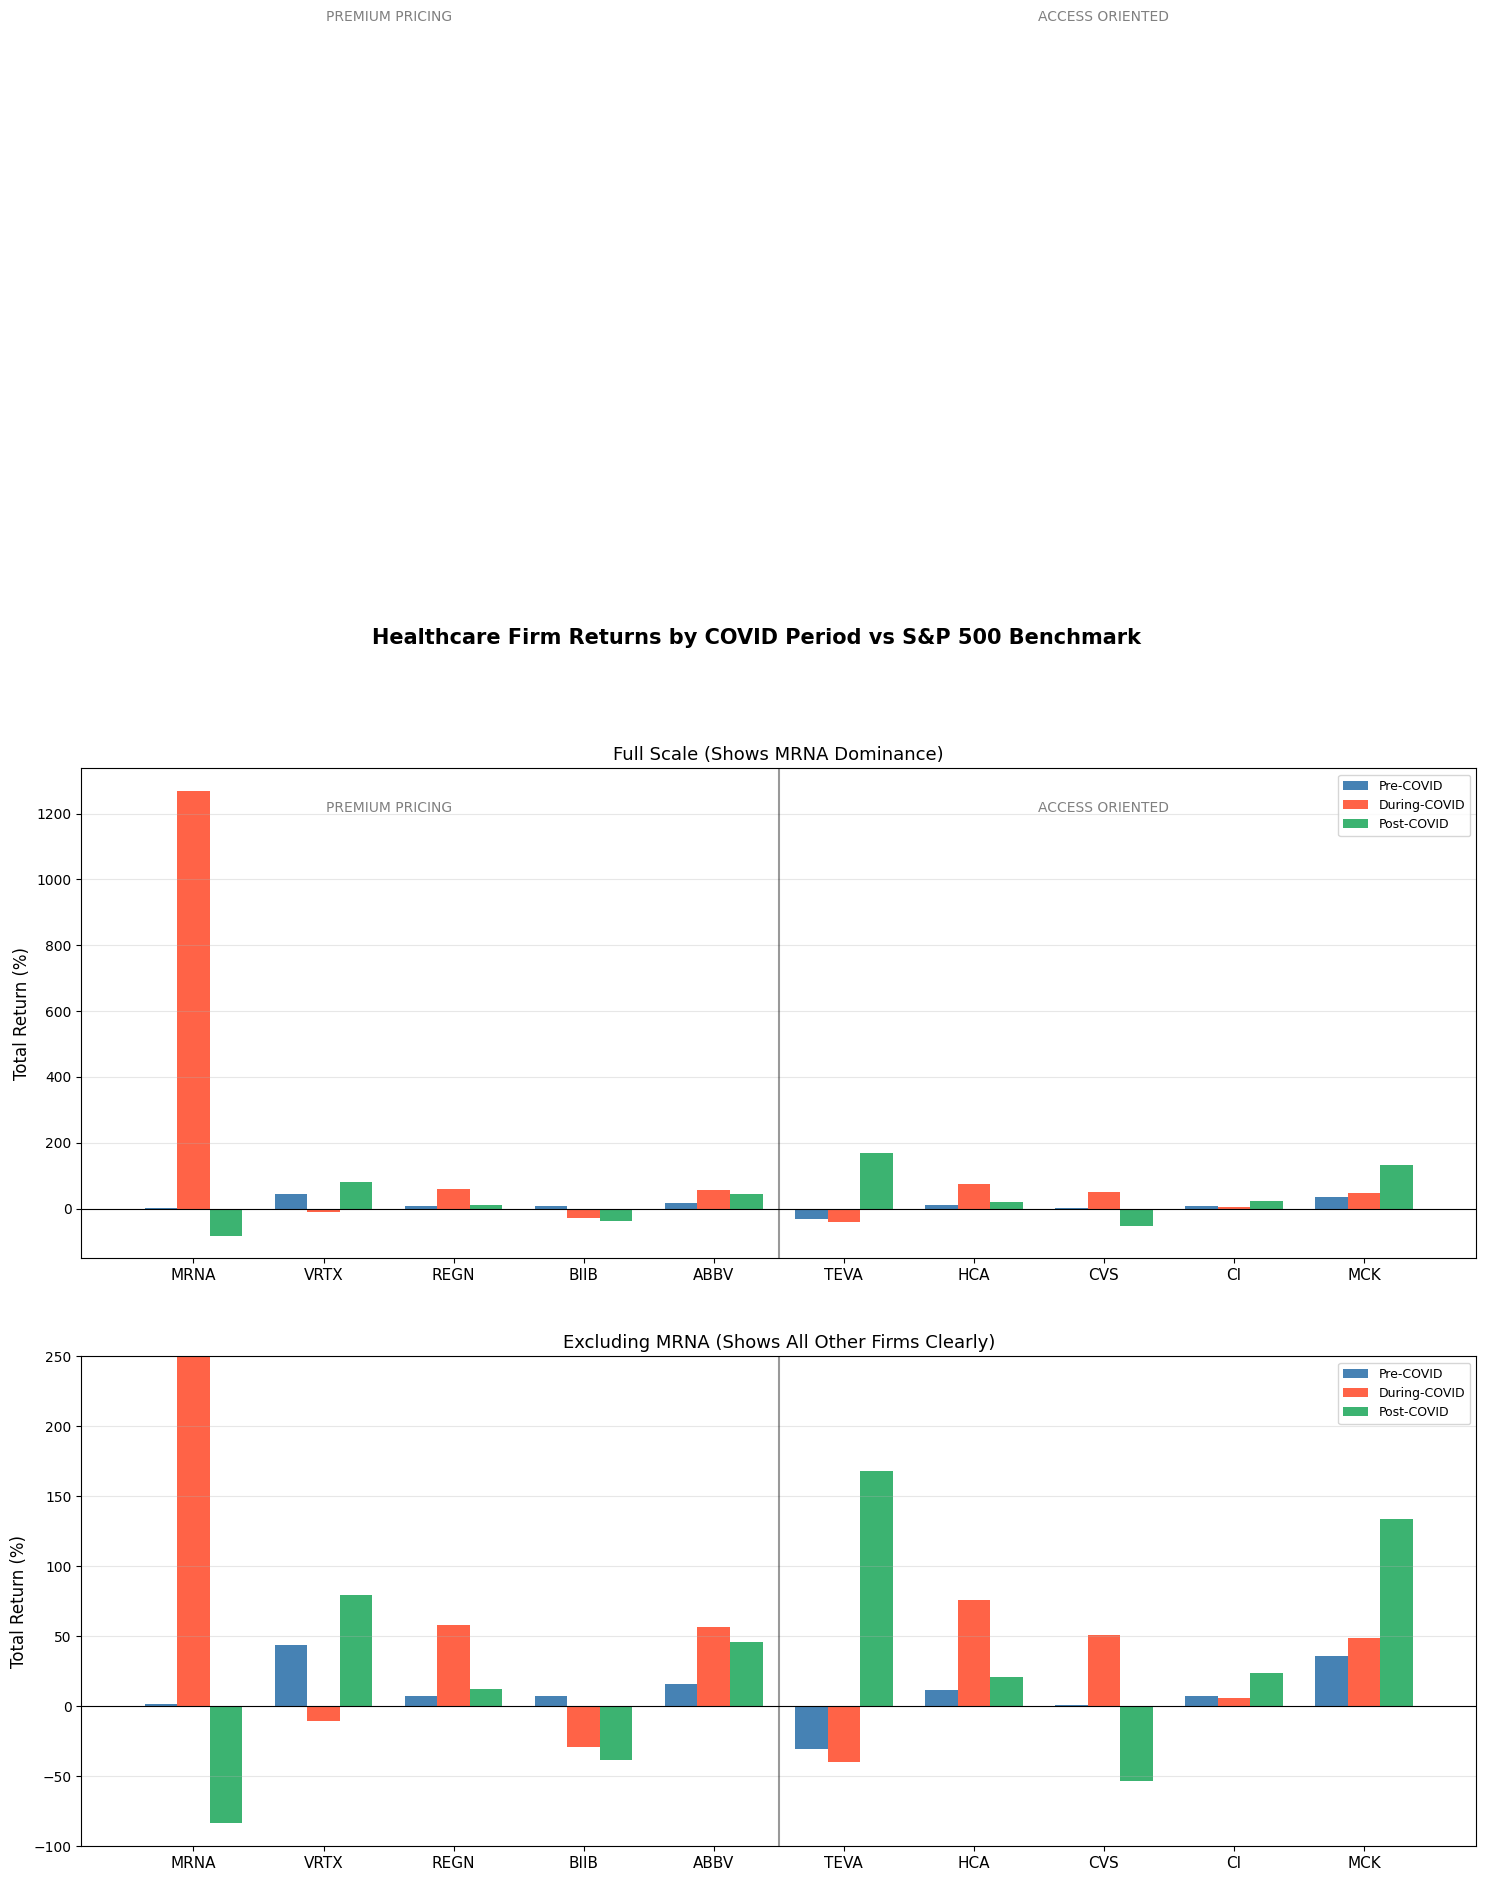

Done


In [5]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Download data
tickers = ['MRNA', 'VRTX', 'REGN', 'BIIB', 'ABBV', 'TEVA', 'HCA', 'CVS', 'CI', 'MCK', '^GSPC']
data = yf.download(tickers, start='2018-12-01', end='2024-12-31')['Close']

# Normalize
normalized = data.copy()
for col in data.columns:
    first_valid = data[col].first_valid_index()
    normalized[col] = data[col] / data[col].loc[first_valid] * 100

# Period returns
tickers_ordered = ['MRNA', 'VRTX', 'REGN', 'BIIB', 'ABBV', 'TEVA', 'HCA', 'CVS', 'CI', 'MCK']
periods_data = {
    'Pre-COVID': ('2018-12-07', '2020-02-19'),
    'During-COVID': ('2020-02-20', '2021-12-31'),
    'Post-COVID': ('2022-01-01', '2024-12-31')
}

returns_matrix = {}
for period, (start, end) in periods_data.items():
    subset = normalized.loc[start:end]
    returns = (subset.iloc[-1] / subset.iloc[0] - 1) * 100
    returns_matrix[period] = returns

# Build bar chart
x = np.arange(len(tickers_ordered))
width = 0.25

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 14))

for ax, title in [(ax1, 'Full Scale (Shows MRNA Dominance)'), (ax2, 'Excluding MRNA (Shows All Other Firms Clearly)')]:
    ax.bar(x - width, [returns_matrix['Pre-COVID'][t] for t in tickers_ordered], width, label='Pre-COVID', color='steelblue')
    ax.bar(x, [returns_matrix['During-COVID'][t] for t in tickers_ordered], width, label='During-COVID', color='tomato')
    ax.bar(x + width, [returns_matrix['Post-COVID'][t] for t in tickers_ordered], width, label='Post-COVID', color='mediumseagreen')
    ax.axhline(y=0, color='black', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(tickers_ordered, fontsize=11)
    ax.set_ylabel('Total Return (%)', fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.axvline(x=4.5, color='black', linewidth=1.5, linestyle='-', alpha=0.4)
    ax.text(1.5, ax.get_ylim()[1]*0.9, 'PREMIUM PRICING', ha='center', fontsize=10, color='gray')
    ax.text(7, ax.get_ylim()[1]*0.9, 'ACCESS ORIENTED', ha='center', fontsize=10, color='gray')

ax2.set_ylim(-100, 250)
fig.suptitle('Healthcare Firm Returns by COVID Period vs S&P 500 Benchmark', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('returns_by_period_dual.png', dpi=150)
plt.show()
print("Done")

KeyError: '2024-12-31'

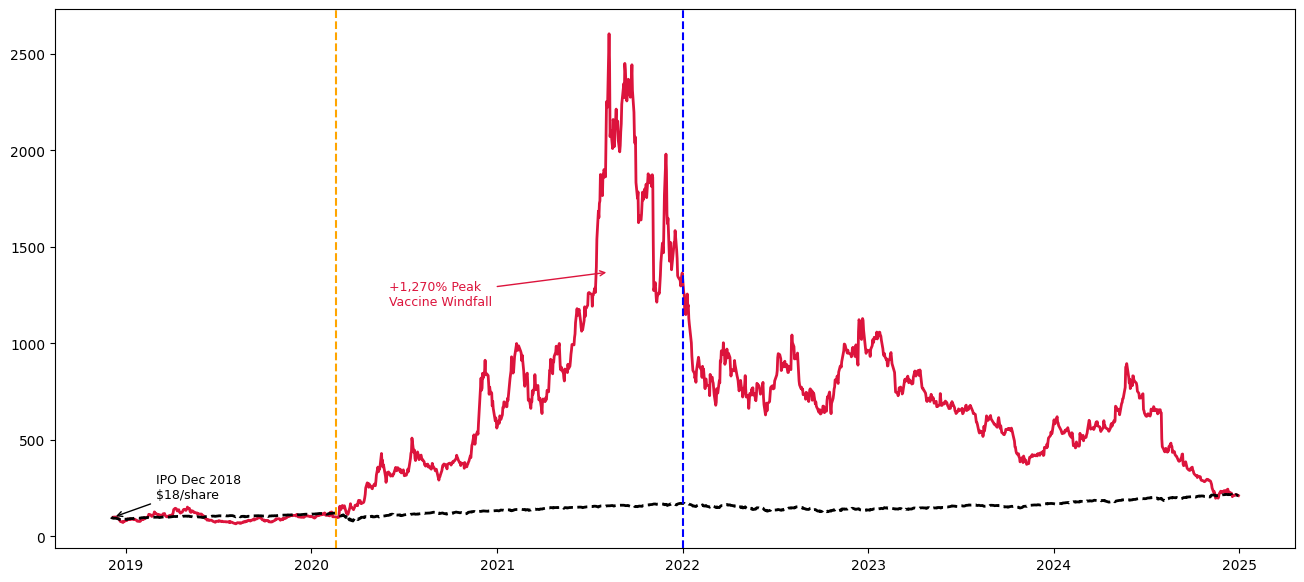

In [6]:
fig, ax = plt.subplots(figsize=(16, 7))

ax.plot(normalized.index, normalized['MRNA'], color='crimson', linewidth=2, label='Moderna (MRNA)')
ax.plot(normalized.index, normalized['^GSPC'], color='black', linewidth=2, linestyle='--', label='S&P 500')

# Mark the three periods
ax.axvline(pd.Timestamp('2020-02-19'), color='orange', linestyle='--', linewidth=1.5, label='COVID Start (Feb 19, 2020)')
ax.axvline(pd.Timestamp('2022-01-01'), color='blue', linestyle='--', linewidth=1.5, label='Post-COVID Start (Jan 1, 2022)')

# Annotate key moments
ax.annotate('IPO Dec 2018\n$18/share', xy=(pd.Timestamp('2018-12-07'), 100), xytext=(pd.Timestamp('2019-03-01'), 200),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=9)

ax.annotate('+1,270% Peak\nVaccine Windfall', xy=(pd.Timestamp('2021-08-09'), 1370),
            xytext=(pd.Timestamp('2020-06-01'), 1200),
            arrowprops=dict(arrowstyle='->', color='crimson'), fontsize=9, color='crimson')

ax.annotate('-83% Collapse\nPost-COVID', xy=(pd.Timestamp('2024-12-31'), normalized['MRNA'].loc['2024-12-31']),
            xytext=(pd.Timestamp('2023-06-01'), 400),
            arrowprops=dict(arrowstyle='->', color='darkred'), fontsize=9, color='darkred')

ax.set_title('Moderna (MRNA): The Premium Pricing Boom and Bust\nPre/During/Post COVID', fontsize=14, fontweight='bold')
ax.set_ylabel('Normalized Price (Base=100)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mrna_story.png', dpi=150)
plt.show()
print("Done")

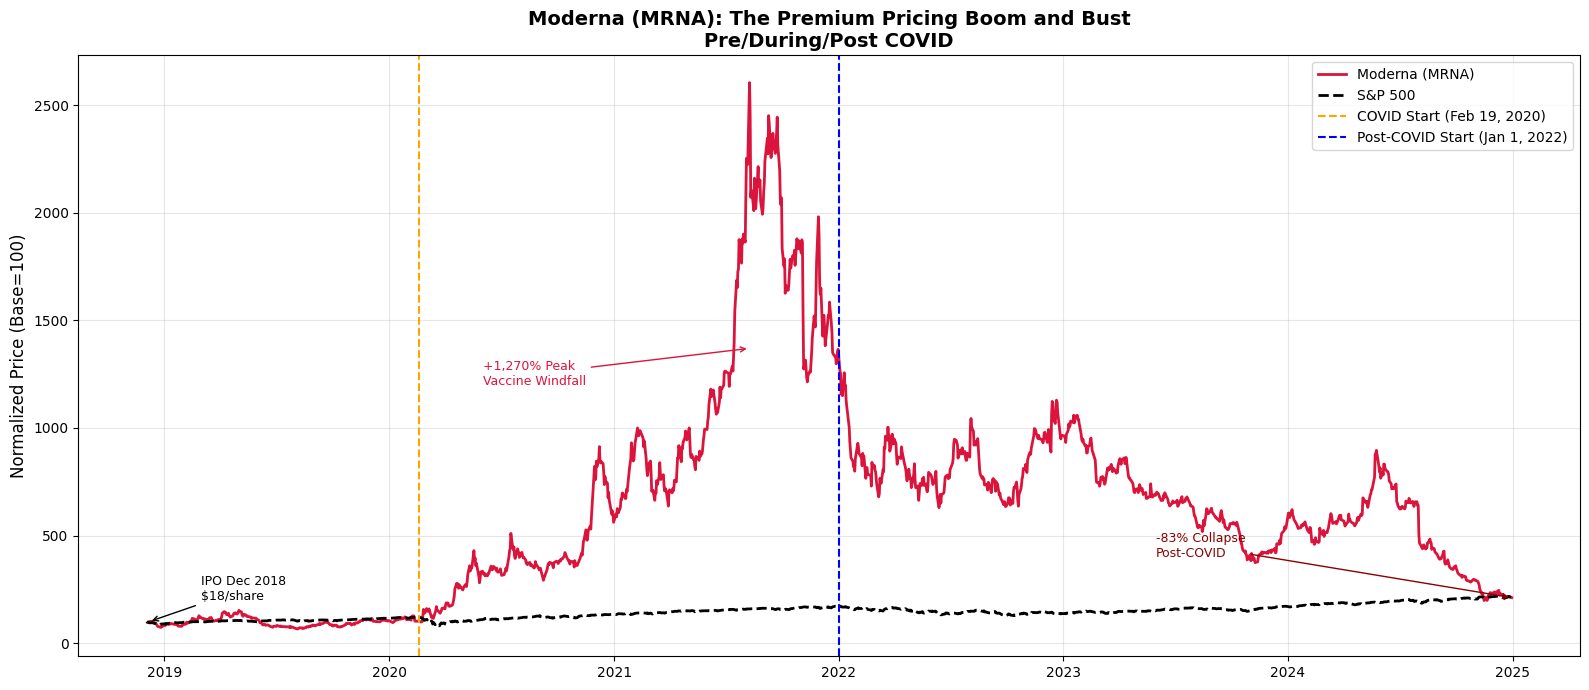

Done


In [7]:
fig, ax = plt.subplots(figsize=(16, 7))

ax.plot(normalized.index, normalized['MRNA'], color='crimson', linewidth=2, label='Moderna (MRNA)')
ax.plot(normalized.index, normalized['^GSPC'], color='black', linewidth=2, linestyle='--', label='S&P 500')

ax.axvline(pd.Timestamp('2020-02-19'), color='orange', linestyle='--', linewidth=1.5, label='COVID Start (Feb 19, 2020)')
ax.axvline(pd.Timestamp('2022-01-01'), color='blue', linestyle='--', linewidth=1.5, label='Post-COVID Start (Jan 1, 2022)')

ax.annotate('IPO Dec 2018\n$18/share', xy=(pd.Timestamp('2018-12-07'), 100),
            xytext=(pd.Timestamp('2019-03-01'), 200),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=9)

ax.annotate('+1,270% Peak\nVaccine Windfall', xy=(pd.Timestamp('2021-08-09'), 1370),
            xytext=(pd.Timestamp('2020-06-01'), 1200),
            arrowprops=dict(arrowstyle='->', color='crimson'), fontsize=9, color='crimson')

# Fix - use last available date dynamically
last_date = normalized['MRNA'].last_valid_index()
last_value = normalized['MRNA'].loc[last_date]
ax.annotate('-83% Collapse\nPost-COVID', xy=(last_date, last_value),
            xytext=(pd.Timestamp('2023-06-01'), 400),
            arrowprops=dict(arrowstyle='->', color='darkred'), fontsize=9, color='darkred')

ax.set_title('Moderna (MRNA): The Premium Pricing Boom and Bust\nPre/During/Post COVID', fontsize=14, fontweight='bold')
ax.set_ylabel('Normalized Price (Base=100)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mrna_story.png', dpi=150)
plt.show()
print("Done")

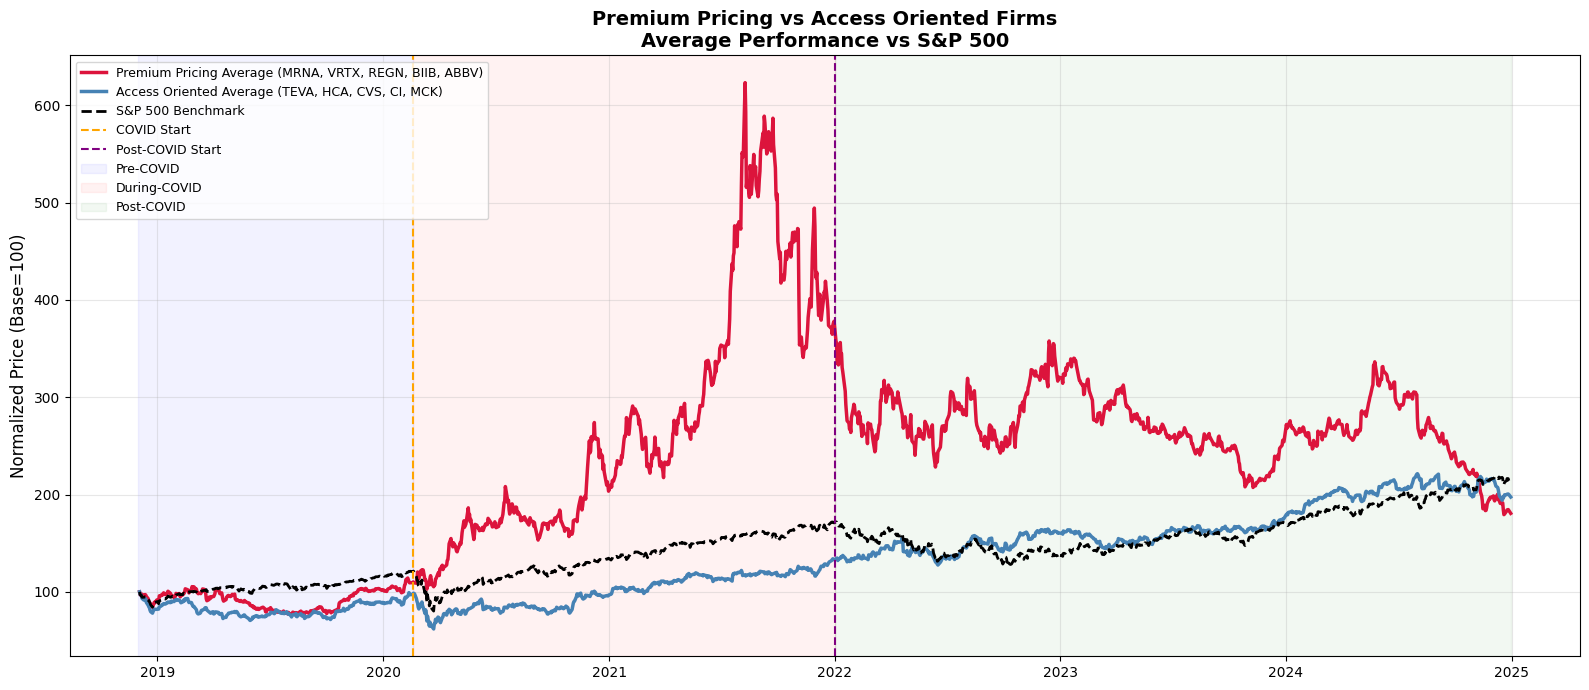

Done


In [8]:
premium = ['MRNA', 'VRTX', 'REGN', 'BIIB', 'ABBV']
access = ['TEVA', 'HCA', 'CVS', 'CI', 'MCK']

normalized['PREMIUM_AVG'] = normalized[premium].mean(axis=1)
normalized['ACCESS_AVG'] = normalized[access].mean(axis=1)

fig, ax = plt.subplots(figsize=(16, 7))

ax.plot(normalized.index, normalized['PREMIUM_AVG'], color='crimson', linewidth=2.5, label='Premium Pricing Average (MRNA, VRTX, REGN, BIIB, ABBV)')
ax.plot(normalized.index, normalized['ACCESS_AVG'], color='steelblue', linewidth=2.5, label='Access Oriented Average (TEVA, HCA, CVS, CI, MCK)')
ax.plot(normalized.index, normalized['^GSPC'], color='black', linewidth=2, linestyle='--', label='S&P 500 Benchmark')

ax.axvline(pd.Timestamp('2020-02-19'), color='orange', linestyle='--', linewidth=1.5, label='COVID Start')
ax.axvline(pd.Timestamp('2022-01-01'), color='purple', linestyle='--', linewidth=1.5, label='Post-COVID Start')

# Shade the three periods
ax.axvspan('2018-12-01', '2020-02-19', alpha=0.05, color='blue', label='Pre-COVID')
ax.axvspan('2020-02-19', '2022-01-01', alpha=0.05, color='red', label='During-COVID')
ax.axvspan('2022-01-01', '2024-12-31', alpha=0.05, color='green', label='Post-COVID')

ax.set_title('Premium Pricing vs Access Oriented Firms\nAverage Performance vs S&P 500', fontsize=14, fontweight='bold')
ax.set_ylabel('Normalized Price (Base=100)', fontsize=12)
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('premium_vs_access.png', dpi=150)
plt.show()
print("Done")

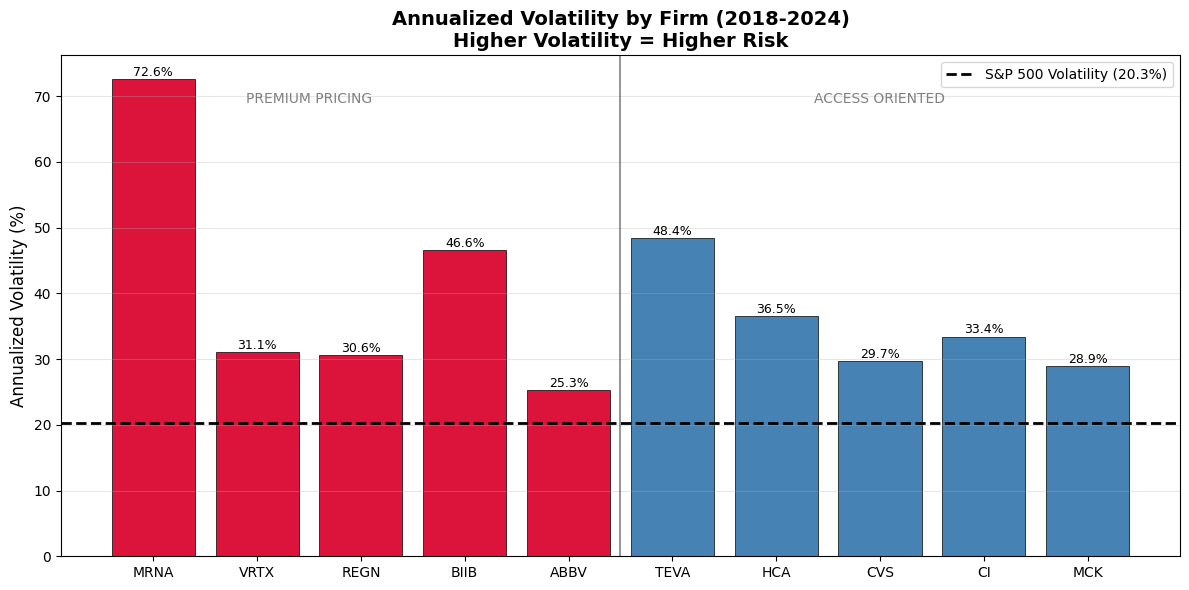

Done


In [9]:
# Calculate annualized volatility (std of daily returns * sqrt(252))
daily_returns = data[tickers_ordered].pct_change().dropna()

volatility = daily_returns.std() * np.sqrt(252) * 100

colors = ['crimson']*5 + ['steelblue']*5

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(tickers_ordered, volatility, color=colors, edgecolor='black', linewidth=0.5)

# Add S&P 500 volatility as reference line
sp_vol = data['^GSPC'].pct_change().dropna().std() * np.sqrt(252) * 100
ax.axhline(y=sp_vol, color='black', linestyle='--', linewidth=2, label=f'S&P 500 Volatility ({sp_vol:.1f}%)')

ax.axvline(x=4.5, color='black', linewidth=1.5, alpha=0.4)
ax.text(1.5, volatility.max()*0.95, 'PREMIUM PRICING', ha='center', fontsize=10, color='gray')
ax.text(7, volatility.max()*0.95, 'ACCESS ORIENTED', ha='center', fontsize=10, color='gray')

ax.set_title('Annualized Volatility by Firm (2018-2024)\nHigher Volatility = Higher Risk', fontsize=14, fontweight='bold')
ax.set_ylabel('Annualized Volatility (%)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, volatility):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('volatility_comparison.png', dpi=150)
plt.show()
print("Done")

In [10]:
# Save the first chart and the data file
fig, ax = plt.subplots(figsize=(16, 8))

for ticker in ['MRNA', 'VRTX', 'REGN', 'BIIB', 'ABBV']:
    ax.plot(normalized.index, normalized[ticker], label=ticker, linewidth=1.5)
for ticker in ['TEVA', 'HCA', 'CVS', 'CI', 'MCK']:
    ax.plot(normalized.index, normalized[ticker], label=ticker, linewidth=1.5, linestyle='dashed')

ax.plot(normalized.index, normalized['^GSPC'], label='S&P 500', color='black', linewidth=2.5)
ax.axvline(pd.Timestamp('2020-02-19'), color='red', linestyle='--', alpha=0.7, label='COVID Start')
ax.axvline(pd.Timestamp('2022-01-01'), color='blue', linestyle='--', alpha=0.7, label='Post-COVID Start')
ax.set_title('Healthcare Firms vs S&P 500: Pre/During/Post COVID', fontsize=16)
ax.set_ylabel('Normalized Price (Base=100)')
ax.legend(loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('healthcare_analysis.png', dpi=150)
plt.close()

# Save CSV
data.to_csv('healthcare_data.csv')

print("Done - now download all files from the sidebar")

Done - now download all files from the sidebar
